<h1> Study of the customer base of the GoFast Scooter Rental Service


- Author: Vorobyeva T. (analyst)
- Date: 08/26/2026

<h1> Project goals and objectives</h1>
<font color='#777778'>
    
**Project goal**: to conduct a research analysis of users of the company’s scooter rental service. Its results will allow managers to obtain an information base for making decisions on the monetization of individual services provided.<br><br>
**Project objectives**:<br>
- Analyze user demographics and scooter usage patterns
- Determine the possible benefits of offering paid scooter subscriptions.
</font>

<h1> Data Description</h1>
<br>
<font color='#777778'>
The customer provided a dataset with data about users and their orders, consisting of the following three tables:

* **Table with users `'users_go.csv'`**
  * `user_id` — unique user identifier.
  * `name` — user name.
  * `age` — age.
  * `city` — city.
  * `subscription_type` — subscription type: free, ultra.

* **rides table `'rides_go.csv'`, incl.:**
  * `user_id` — unique user identifier.
  * `distance` — distance in meters that the user has traveled in the current session.
  * `duration` — duration of the session in minutes, that is, the time from the moment the user clicked the “Start ride” button until the user clicked the “End ride” button.
  * `date` — date of the ride.

* **Subscriptions table `'subscriptions_go.csv'`, incl.:**
  * `subscription_type` — subscription type.
  * `minute_price` — the cost of one ride minute for this subscription.
  * `start_ride_price` — cost of starting the ride.
  * `subscription_fee` — monthly payment cost.
.</font>

<h1> Project Contents</h1>
<font color='#777778'>
The research plan was drawn up using ETL and data analysis methodology and includes the following main stages:<br>
- Loading data and getting to know it<br>
- Data preprocessing<br>
- Exploratory data analysis<br>
- Formation of hypotheses<br>
- Final conclusion and recommendations</font>


<h1> 2. Loading data and getting to know it </h1>

- Load the libraries for work, then load data about users, rides and subscriptions from the tables of the same name.


In [49]:
# Load the libraries.
# We will use pandas and the data visualization libraries matplotlib and seaborn, as well as phik to build the correlation matrix.
# Importing libraries.
!pip install matplotlib seaborn phik st
import pandas as pd
import numpy as np
import scipy.stats as st

# Load libraries for data visualization.
import matplotlib.pyplot as plt
import seaborn as sns

# Load the library to calculate the correlation coefficient phi_k.
from phik import phik_matrix 


In [50]:
# Load the data to the variables df_users_go, df_rides_go and df_subscriptions_go.

try:
    # We look for the file directly in the folder on the computer
    df_users_go = pd.read_csv('users_go.csv')
    df_rides_go = pd.read_csv('rides_go.csv')
    df_subscriptions_go = pd.read_csv('subscriptions_go.csv')
    
except Exception as e:
    # Fallback remote URL
    df_users_go = pd.read_csv('https://code.s3.yandex.net/datasets/users_go.csv')
    df_rides_go = pd.read_csv('https://code.s3.yandex.net/datasets/rides_go.csv')
    df_subscriptions_go = pd.read_csv('https://code.s3.yandex.net/datasets/subscriptions_go.csv') 

# Show all columns
pd.set_option('display.max_columns', None)

# Show all rows
pd.set_option('display.max_rows', 20)

In [3]:
# Display the first rows of the df_users_go dataframe on the screen.
df_users_go.head(5) 

,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra


Get acquainted with the data and study general information about it.

In [4]:
# Display information about the dataframe.
df_users_go.info()


<class 'pandas.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   user_id            1565 non-null   int64
 1   name               1565 non-null   str  
 2   age                1565 non-null   int64
 3   city               1565 non-null   str  
 4   subscription_type  1565 non-null   str  
dtypes: int64(2), str(3)
memory usage: 61.3 KB


The 'df_users_go' dataset contains 5 columns and 1565 rows, which provide information about users (id, name, age, city, subscription type). 

There are no missing values.
Most of the data in the dataset is text (3 columns are of str type), only 2 columns are of numeric type (int64): 'user_id' and 'age'.

Thus, the quality of the data is quite high: there are no missing values and the data format is generally correct, although the format in the 'user_id' and 'age' columns clearly needs to be downcasted, which will save memory when storing this data. 
However, we need to check all columns for possible anomalous values, invalid words or characters (for example, hyphens or tokens - 'unknown', 'tbd').

In [5]:
# Display the first rows of the df_rides_go dataframe on the screen.
df_rides_go.head()

,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28


In [6]:
# Display information about the dataframe.
df_rides_go.info()


<class 'pandas.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   18068 non-null  int64  
 1   distance  18068 non-null  float64
 2   duration  18068 non-null  float64
 3   date      18068 non-null  str    
dtypes: float64(2), int64(1), str(1)
memory usage: 564.8 KB


The 'df_rides_go' dataset contains 4 columns and 18068 rows containing e-scooter ride details such as distance, duration and date.
There are completely no missing values ​​in the dataset-all 18,068 rows are filled in all columns.
One column is a text format (str), two columns are a floating point numeric type (float64), and one column is an integer type (int64). 
Further steps for data preprocessing:
- **Changing data type for dates**: The date column has a text data type (str). To carry out correct time analysis, it must be converted to the datetime64 format. 
- **Data type optimization**: The user_id column is represented as an int64. It can be cast to a more compact integer type (for example, Int32) to save RAM.  The distance and duration columns use the float64 type. Using the float32 type for distance and duration will reduce the amount of memory required without losing calculation accuracy.


In [7]:
# Display the first rows of the df_subscriptions_go dataframe on the screen.
df_subscriptions_go.head()

,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


In [8]:
# Display information about the dataframe.
df_subscriptions_go.info()


<class 'pandas.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   subscription_type  2 non-null      str  
 1   minute_price       2 non-null      int64
 2   start_ride_price   2 non-null      int64
 3   subscription_fee   2 non-null      int64
dtypes: int64(3), str(1)
memory usage: 196.0 bytes


- The 'df_subscriptions_go' dataset contains 4 columns and 2 rows, which present the parameters of subscriptions, such as the cost of a ride minute, the cost of starting and the subscription fee.<br>
- There are no missing values in the dataset.<br>
- One column is in text format (str) and the other three columns are in integer data type (int64).<br>
- For the minute_price, start_ride_price, and subscription_fee columns, the int64 data type is clearly redundant. We will convert their format to a more compact integer type (Int16) to optimize memory use.

<div class="alert alert-info">
    
<h1> Key takeaways of the data familiarization stage</h1>

The studied datasets contain detailed information about the customer base and rides. The column names correspond to the data in them. There are no missing values, but in some cases it is necessary to correct the data types.
Therefore, it is necessary to preprocess the data:<br> 
- check for duplicates, anomalous values or incorrect characters;
- bring data types to the correct format.

<h1> 3. Data preprocessing</h1>
- Check for unique values in key columns. First, we will convert the values in the 'name' and 'city' columns to lower case and remove any possible spaces.<br>
- Let’s check for noise or invalid entries”.<br>
- We will correct data formats where necessary.<br>
- We will check the columns for possible missing data, anomalous values and outliers.<br>
- Check relevant columns for explicit and implicit duplicates.<br>
</br>

In [9]:
# Convert the values in the 'name' and 'city' columns to lower case and remove any possible spaces.
df_users_go['name'] = df_users_go['name'].astype(str).str.lower().str.strip()
df_users_go['city'] = df_users_go['city'].astype(str).str.lower().str.strip()


In [10]:
# Output unique values.

# Create a dictionary with the dataframes being studied.
dataframes = {
    'Users': df_users_go,
    'Rides': df_rides_go,
    'Subscriptions': df_subscriptions_go
}

# Display unique values for the numeric columns of each dataframe.
for name, df in dataframes.items():
    print(f'Analysis of unique values in the dataset "{name}":')
    for column in df.columns:
        stats_df = pd.DataFrame({
        'Data type': df.dtypes,
        'Unique values': df.nunique()
    })
    display(stats_df)

Analysis of unique values in the dataset "Users":


,Data type,Unique values
user_id,int64,1534
name,str,194
age,int64,29
city,str,8
subscription_type,str,2


Analysis of unique values in the dataset "Rides":


,Data type,Unique values
user_id,int64,1534
distance,float64,18068
duration,float64,17974
date,str,364


Analysis of unique values in the dataset "Subscriptions":


,Data type,Unique values
subscription_type,str,2
minute_price,int64,2
start_ride_price,int64,2
subscription_fee,int64,2


Examination of the unique values revealed the following:<br>
For the 'Users' dataframe:<br>
The table contains 1,534 unique user_ids. The database is represented by 194 unique names, 29 ages, 8 cities of presence and 2 subscription types (free and ultra).<br><br> According to the 'Rides' dataframe: Rides of the same 1,534 users were recorded, which indicates the absence of “empty” accounts.<br> The date field covers 364 unique days (almost a full calendar year).<br> The distance and duration metrics demonstrate high variability (18 054 and 17,963 unique values).<br><br> For the 'Subscriptions' dataframe: The table contains exactly 2 records with parameter values for each subscription type.<br>  
Features identified:<br>
Time series anomaly: A value of 364 in the date field indicates that 1-2 days of data per year are missing. This may be due to a technical failure of the upload or a temporary suspension of the service (for example, due to adverse weather conditions or holidays).<br> A large number of unique distance and duration values ​​confirms that the data was collected with high measurement accuracy.

In [11]:
# Set a list of suspicious text values.
stop_words = ['no data', 'unknown', 'free', 'null', 'none', '-', 'n/a', '?']

# Check the text columns for implicit missing values and hidden garbage.
for name, df in dataframes.items():
    print(f'Checking for implicit textual anomalies in the dataset "{name}":')
    for column in df.select_dtypes(include=['object', 'string']).columns:
        # Convert the text to lower case and remove outer spaces for accurate verification.
        clean_series = df[column].astype(str).str.strip().str.lower()
        
        # Count matches with stop words.
        garbage_mask = clean_series.isin(stop_words)
        garbage_count = garbage_mask.sum()
        
        if garbage_count > 0:
            print(f'Column {column}: Implicit anomalies found - {garbage_count}')
            display(df[garbage_mask][column].value_counts())
        else:
            print(f'Column {column}: Implicit text anomalies were not detected.')

Checking for implicit textual anomalies in the dataset "Users":
Column name: Implicit text anomalies were not detected.
Column city: Implicit text anomalies were not detected.
Column subscription_type: Implicit anomalies found - 846


subscription_type
free    846
Name: count, dtype: int64

Checking for implicit textual anomalies in the dataset "Rides":
Column date: Implicit text anomalies were not detected.
Checking for implicit textual anomalies in the dataset "Subscriptions":
Column subscription_type: Implicit anomalies found - 1


subscription_type
free    1
Name: count, dtype: int64

In [12]:
# In the 'df_users_go' dataframe, replace the data format in the 'user_id' column with Int32 and in the 'age' column with Int8.
df_users_go['user_id'] = df_users_go['user_id'].astype('Int32')
df_users_go['age'] = df_users_go['age'].astype('Int8')

# In the df_rides_go dataframe, replace the data format in the 'date' column with a pandas date type, in the 'user_id' column with Int32, in the 'distance' column with float32 and 'duration' with int64.
df_rides_go['date'] = pd.to_datetime(df_rides_go['date'], errors='coerce')
df_rides_go['user_id'] = df_rides_go['user_id'].astype('Int32')
df_rides_go['distance'] = df_rides_go['distance'].astype('float32')
df_rides_go['duration'] = df_rides_go['duration'].astype('int64')

# In the 'df_subscriptions_go' dataframe, replace the data format of the 'minute_price', 'start_ride_price' and 'subscription_fee' columns with Int16.
df_subscriptions_go[['minute_price', 'start_ride_price', 'subscription_fee']] = (df_subscriptions_go[['minute_price', 'start_ride_price', 'subscription_fee']]).astype('Int16')


In [13]:
# Display statistical indicators for numeric columns.

# Create a dictionary with the dataframes being studied.
dataframes = {
    'Users': df_users_go,
    'Rides': df_rides_go,
    'Subscriptions': df_subscriptions_go
}

# Display statistical indicators for the numeric columns of each dataframe.
for name, df in dataframes.items():
    print(f'Dataset summary statistics "{name}":')
    display(df.describe().round(2))
    

Dataset summary statistics "Users":


,user_id,age
count,1565.0,1565.0
mean,762.63,24.92
std,443.26,4.55
min,1.0,12.0
25%,378.0,22.0
50%,762.0,25.0
75%,1146.0,28.0
max,1534.0,43.0


Dataset summary statistics "Rides":


,user_id,distance,duration,date
count,18068.0,18068.00,18068.00,18068
mean,842.87,3070.66,17.30,2021-06-30 19:47:21.266327
min,1.0,0.86,0.00,2021-01-01 00:00:00
25%,487.0,2543.23,13.00,2021-04-02 00:00:00
50%,889.0,3133.61,17.00,2021-06-30 00:00:00
75%,1213.25,3776.22,21.00,2021-09-28 00:00:00
max,1534.0,7211.01,40.00,2021-12-30 00:00:00
std,434.73,1116.83,6.09,NaN


Dataset summary statistics "Subscriptions":


,minute_price,start_ride_price,subscription_fee
count,2.0,2.0,2.0
mean,7.0,25.0,99.5
std,1.41,35.36,140.71
min,6.0,0.0,0.0
25%,6.5,12.5,49.75
50%,7.0,25.0,99.5
75%,7.5,37.5,149.25
max,8.0,50.0,199.0


Analysis of the statistical values of the numeric columns of the dataframe revealed the following:
- According to the 'df_users_go' dataset: The table contains 1,565 records with a maximum user_id = 1,534 (minimum 31 duplicates). 
Users' ages range from 12 to 43 years, with a mean of 24.92 years and a median of 25.0 years.<br>
- According to the 'df_rides_go' dataset: 18,068 rides were recorded from January 1 to December 30, 2021. The average distance is 3,070.66 meters (median - 3,133.61 meters), the average duration is 17.81 minutes (median - 17.68 minutes). The closeness of the means and medians for distance and duration indicates the close to normal nature of their distribution. <br> 
- According to the 'df_subscriptions_go' dataset: 2 subscriptions are described with the cost per minute in the range of 6–8 rubles, the cost of the first ride in the range of 0.0–50.0 rubles. and subscriptions from 0 to 199 rubles<br> 

Analysis of the critical values showed that, in general, they correspond to the norm.
Features requiring further study:<br> 
- Abnormally low session durations and distances (0.5 minutes and 0.86 meters) may be caused by starting errors, scooter malfunctions, or immediate cancellations.
- Missing date: The last recorded date is December 30, 2021, which explains the presence of 364 unique days in the database due to an upload failure or technical downtime.

<h1> Anomaly filtering</h1>

In [14]:
# Check the number of near-zero values ​​in the session duration and distance columns.
distance_nulls = (df_rides_go['distance']<1).sum()
duration_nulls = (df_rides_go['duration']<1).sum()

# Display the number of values ​​found.
print(distance_nulls, duration_nulls)


1 95


Outliers in the 'duration' and 'distance' columns make up about 0.5% of the records in the dataset, so we will replace these near-zero values ​​with missing values.


In [15]:
# Convert the zeros to NaN.
df_rides_go['distance'] = np.where(df_rides_go['distance'] < 1, np.nan, df_rides_go['distance'])
df_rides_go['duration'] = np.where(df_rides_go['duration'] < 1, np.nan, df_rides_go['duration'])


In [16]:
# Check the number of near-zero values ​​in the session duration and distance columns.
distance_nulls = (df_rides_go['distance']<1).sum()
duration_nulls = (df_rides_go['duration']<1).sum()

# Display the number of values ​​found.
print(distance_nulls, duration_nulls)


0 0


In [17]:
# Check how the statistical indicators have changed after filtering and how many rows are left in the dataframe.
display(df_rides_go.describe().round(2))


,user_id,distance,duration,date
count,18068.0,18067.00,17973.00,18068
mean,842.87,3070.83,17.39,2021-06-30 19:47:21.266327
min,1.0,2.57,2.00,2021-01-01 00:00:00
25%,487.0,2543.35,13.00,2021-04-02 00:00:00
50%,889.0,3133.67,17.00,2021-06-30 00:00:00
75%,1213.25,3776.25,21.00,2021-09-28 00:00:00
max,1534.0,7211.01,40.00,2021-12-30 00:00:00
std,434.73,1116.63,5.98,NaN


As you can see, after cutting off the anomalous values, the values ​​of the mean and standard deviation leveled off a little. It was decided to leave the rowa with missing values (which filled the near-zero duration values) as is.

Check the typical values ​​in the 'distance' and 'duration' columns.

<Axes: ylabel='Frequency'>

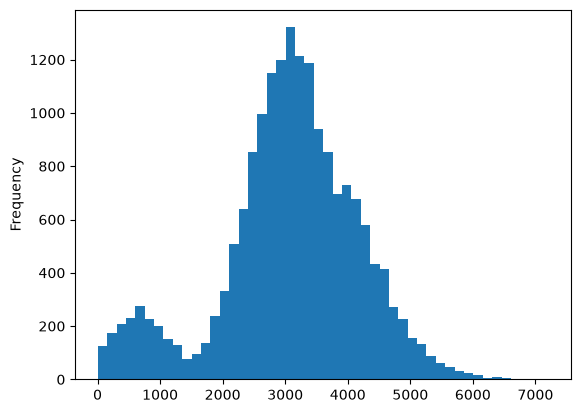

In [18]:
# Build a histogram using plot(kind='hist').
df_rides_go['distance'].plot(kind='hist', bins=48)


Distribution shape: Two-peak (bimodal) distribution. The first peak is located in the area of ​​500–800 meters, the second (main) is about 3,000 meters.

Nature of the small peak: A burst in the region of 500–1000 meters is not technical debris or an anomaly. This is a separate user scenario - “short rides” (getting from the metro to home, to the nearest store, or transfer).
Therefore, we will not filter small values.

<Axes: ylabel='Frequency'>

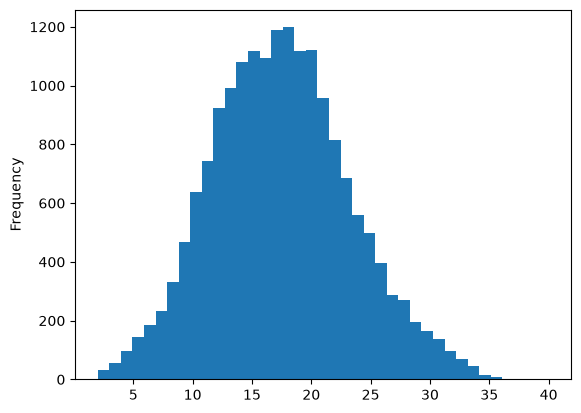

In [19]:
# Build a histogram using plot(kind='hist').
df_rides_go['duration'].plot(kind='hist', bins=39)

The presence of small values ​​- up to 5 minutes - is probably due to technical errors in use, leading to the ride being reset. But for now we will leave them as they are.

<h1> Check for duplicates.</h1>

In [20]:
# Find exact duplicates in the 'Users' dataframe.
df_users_go.duplicated().sum() 

# Find partial duplicates using the 'user_id' column.
df_users_go.duplicated(subset='user_id').sum() 

np.int64(31)

In the 'df_users_go' dataset, all 31 extra rows found are complete, obvious duplicates, likely caused by a technical failure in unloading the database. Delete these rows and update the dataframe index.

In [51]:
# Remove exact duplicates.
df_users_go = df_users_go.drop_duplicates().reset_index(drop=True)

print(f"New row count in the 'Users' dataframe: {len(df_users_go)}")


New row count in the 'Users' dataframe: 1534


<h1> Round up the duration of the ride.</h1>

In the dataframe 'df_rides_go', we will round the ride time 'duration' to an integer using the standard round() method.<br> 
Then we will cast this column to the integer type 'int'. This step will then help us calculate the profit since the users are only charged for a whole number of minutes.

In [22]:
df_rides_go['duration'] = df_rides_go['duration'].round(2)
df_rides_go['duration'] = pd.to_numeric(df_rides_go['duration'])

<div class="alert alert-info">
    
<h1> Conclusions on data preprocessing:</h1>
- In general, the data for all three dataframes demonstrate a fairly high quality of filling in critical features for further segmentation and analysis (user_id, name, duration, distance age). <br>

- A small number of rows with obvious duplicates have been removed from the 'Users' table.<br>


<h1>4. Study the key columns of the dataframe</h1>

Describe and visualize general information about users and rides:<br>
• frequency of occurrence of cities;
• ratio of users with and without subscription;<br>
• age of users;<br>
• the distance the user covered in one ride;<br>
• duration of rides.<br>
 <br> 
We will research each respective column "one-by-one".<br>

<h1>City </h1>
Study frequency of mentioning cities.


In [23]:
city_frequency = (df_users_go['city']).value_counts()
frequency_percent = (df_users_go['city'].value_counts() / len(df_users_go)*100).round(2)
frequency_table=pd.DataFrame({'Mention count': city_frequency, 'Frequency in %': frequency_percent}).reset_index()
display(frequency_table)


,city,Mention count,Frequency in %
0,пятигорск,219,14.28
1,екатеринбург,204,13.30
2,ростов-на-дону,198,12.91
3,краснодар,193,12.58
4,сочи,189,12.32
5,омск,183,11.93
6,тюмень,180,11.73
7,москва,168,10.95


<div class="alert alert-info">
    
* **Rating leader - Pyatigorsk:** The city takes first place with 219 mentions (14.28% of the total sample).
* **Top outsider - Moscow:** Occupies the smallest share among the presented cities with 168 mentions (10.95%).
* **Evenness of distribution:** The difference between the maximum share (Pyatigorsk - 14.28%) and the minimum share in the top (Moscow - 10.95%) is only **3.33 percentage points**. The spread of indicators is minimal.
* **Geographical representation:** The top includes regional centers of the South of Russia (Pyatigorsk, Rostov-on-Don, Krasnodar, Sochi), the Urals (Ekaterinburg, Tyumen), Siberia (Omsk) and the Central Federal District (Moscow).

<h1> Subscription type.</h1>
Analyse the ratio of users with subscription and without subscription.

In [24]:
# Calculate the number of users with and without an ultra subscription.
paying_customers = (df_users_go['subscription_type'] == 'ultra').sum()
free_customers = len(df_users_go) - paying_customers

# Calculate the relative shares of users in each segment.
paying_customers_percent = (paying_customers / len(df_users_go)) * 100
free_customers_percent = 100 - paying_customers_percent

# Calculate the ratio of free users to paying ones.
ratio = free_customers_percent / paying_customers_percent 

# Create a summary dataframe with subscription distribution statistics.
subscriptions_table = pd.DataFrame({
    'Number of paying (ultra) users': [paying_customers], 
    'Number of free users': [free_customers], 
    'Share of paying users (%)': [round(paying_customers_percent, 2)], 
    'Share of free users(%)': [round(free_customers_percent, 2)], 
    'Ratio (Free / Ultra)': [round(ratio, 2)]
})

# Display the final table of user distribution by subscription type.
display(subscriptions_table)


,Number of paying (ultra) users,Number of free users,Share of paying users (%),Share of free users(%),Ratio (Free / Ultra)
0,699,835,45.57,54.43,1.19


<div class="alert alert-info">
    
**User ratio**: The cleaned database contains 835 users without a subscription (54.43%) and 699 users with an ultra subscription (45.57%).  
**Ratio Value**: The ratio of non-subscription users to paying customers is 1.19. This means that for every 100 ultra subscribers, there are 119 free users.

<h1> User age </h1>


Study the distribution of service users by age groups.

In [25]:
# Set the boundaries of age intervals.
age_bins = [0, 18, 30, 45]

# Write text names for these intervals.
age_labels = ['Children and teenagers (0-18)', 'Young people (18-35)', 'Middle age (35-45)']

# Create a new column using the pd.cut function. The lower boundaries of the intervals will be included in the corresponding group, but the upper ones will not (the 'right=False' parameter)
df_users_go['age_group'] = pd.cut(
    df_users_go['age'], 
    bins=age_bins, 
    labels=age_labels, right=False
)

# Display it on the screen.
print(df_users_go[['age', 'age_group']].head())


   age             age_group
0   22  Young people (18-35)
1   31    Middle age (35-45)
2   20  Young people (18-35)
3   26  Young people (18-35)
4   28  Young people (18-35)


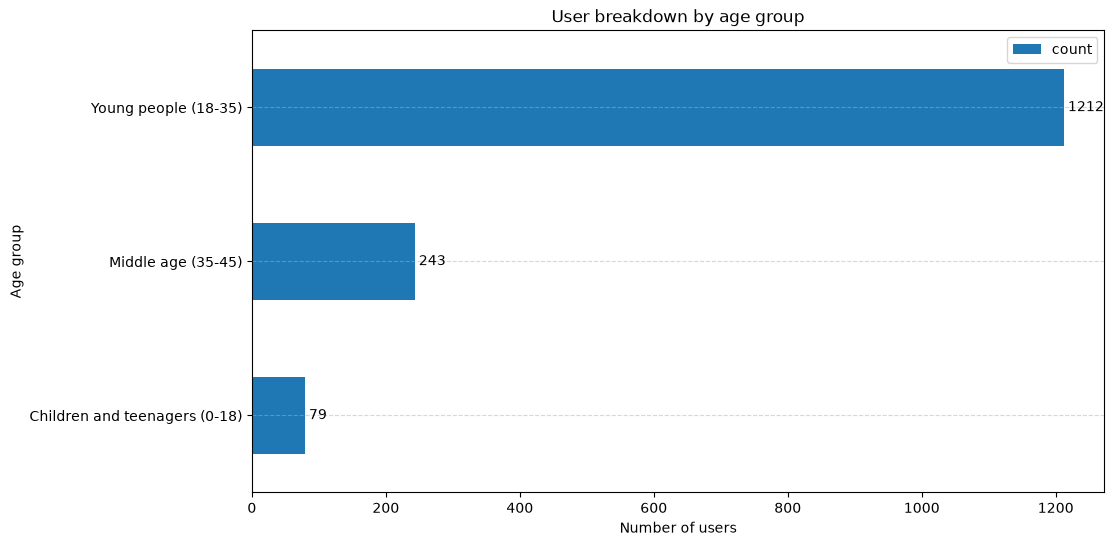

In [26]:
# Build a bar chart using pandas via plot (kind='bar').
df = df_users_go['age_group'].value_counts()

# Sort the values in descending order.
df_sorted = df.sort_values(ascending=True)

# Build a bar chart using pandas via plot(kind='bar').
ax=df_sorted.plot(
               kind='barh', 
               rot=0, 
               legend=True,
               figsize=(11, 6),
               title=f'User breakdown by age group'
)

# Add row values.
# Pass the column containers to ax.containers[0]
ax.bar_label(ax.containers[0], padding=3) 

# Set up the graphics design.
plt.ylabel('Age group')
plt.xlabel('Number of users')

# Add a graph grid.
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Display the graph on the screen.
plt.show()


<div class="alert alert-info">

- The “Youth (18-35)” group is the largest and has 1212 users, which is 79.01% of the total (1534 users).
- The “Young Adults (35-45)” group takes second place with 243 users (15.84%).
- The group “Children and teenagers (0-18)” is the smallest and has 79 users (5.15%).
- The total share of users over 18 years of age is 94.85% (1455 users).

<h1> Distance traveled in one ride</h1>


* In the previous section, we have already plotted the distribution of distance values throughout the entire dataframe. <br>
* In this section, we will group these values into distance intervals that can later be used when segmenting the user base.<br>
* To do this, we group all the data into the following groups, focusing on the values of the main quartiles (25, 50 and 75%) and extreme values: from 1 to 1500 m, from 1500 to 3000 m, from 3000 to 4500 m, over 4500 m.

In [27]:
# Set the boundaries of the distance intervals.
distance_bins = [1, 1500, 3000, 4500, 7211.01]

# Write text names for these intervals.
distance_labels = ['Short (1-1500 m)', 'Middle (1500-3000 m)', 'Long (3000-4500 m)', 'Very long (4500-7211.01 m)']

# Create a new column using the pd.cut function. The lower boundaries of the intervals will be included in the corresponding group, but the upper ones will not (the 'right=False' parameter)
df_rides_go['distance_group'] = pd.cut(
    df_rides_go['distance'], 
    bins=distance_bins, 
    labels=distance_labels, right=False
)

# Display it on the screen.
print(df_rides_go[['distance', 'distance_group']].head())


      distance        distance_group
0  4409.918945    Long (3000-4500 m)
1  2617.592041  Middle (1500-3000 m)
2   754.159790      Short (1-1500 m)
3  2694.783203  Middle (1500-3000 m)
4  4028.687256    Long (3000-4500 m)


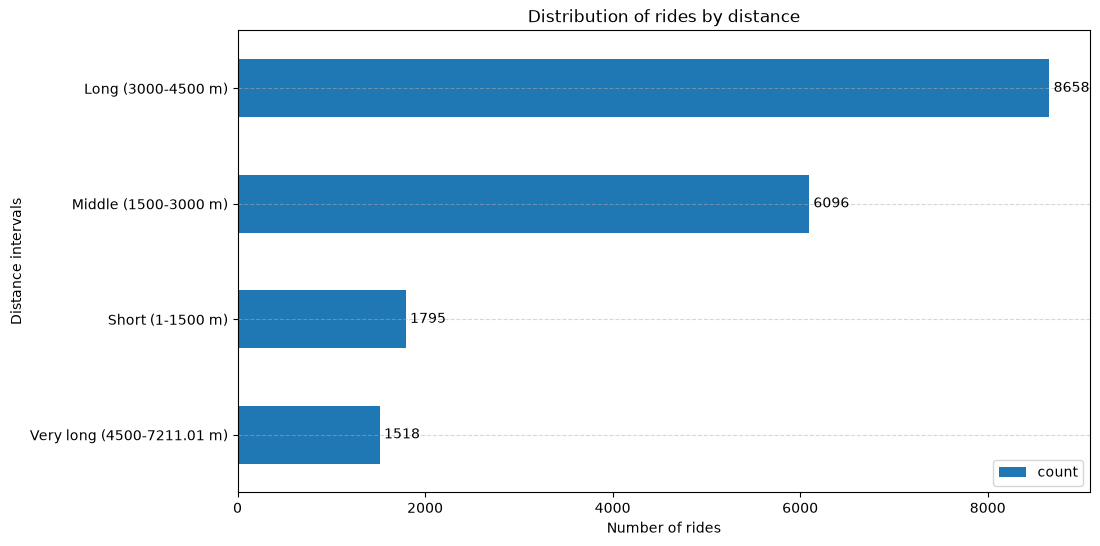

In [28]:
# Build a bar chart using pandas via plot(kind='bar').
df_distance = df_rides_go['distance_group'].value_counts()

# Sort the values in descending order.
df_distance_sorted = df_distance.sort_values(ascending=True)

# Build a bar chart using pandas via plot(kind='bar').
ax=df_distance_sorted.plot(
               kind='barh', 
               rot=0, 
               legend=True, 
               figsize=(11, 6),
               title=f'Distribution of rides by distance'
)

# Add row values.
# Pass the column containers to ax.containers[0]
ax.bar_label(ax.containers[0], padding=3) 

# Set up the graphics design.
plt.ylabel('Distance intervals')
plt.xlabel('Number of rides')

# Add a graph grid.
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Display the graph on the screen.
plt.show()


<div class="alert alert-info">
<h1> Interim conclusions on distance:</h1>
    
* **Total volume of the analyzed sample**: A total of 18,067 rides were recorded on the graph.<br>
* **"Long distance" (3000-4500 m)**: This interval is the absolute leader in the number of rides - 8658 rides (which is 47.92% of the total).<br>
* **"Average distance" (1500-3000 m)**: The second largest segment accounts for 6096 rides (33.74% of all rides).<br>
* **Total share of main intervals:** Medium and long distance rides (from 1500 to 4500 meters) total 81.66% (14754 rides).<br>
* **Smaller segments:**<br>
  * **"Short distance" (1-1500 m):** 1795 rides recorded (9.94%).<br>
  * **“Maximum distance” (4500-7211.01 m):** The least popular interval is 1518 rides (8.40%).

# Duration of rides


* In the previous section 2, we have already plotted the distribution of ride duration values throughout the entire dataframe.<br>
* In this section, we will group the values by conventional duration intervals, which can later be used when segmenting the user base.<br>
* To do this, we will group all the data into the following groups, focusing on the values of the main quartiles (25, 50 and 75%) and extreme values: from 1 to 10 minutes, from 10 minutes to 20 minutes, from 20 minutes to 30 minutes, from 30 minutes to 40.82 minutes.

In [29]:
# Set the boundaries of duration intervals.
duration_bins = [1, 10, 20, 30, 40.82]

# Write text names for these intervals.
duration_labels = ['Short (1-10 minutes)', 'Middle (10-20 minutes)', 'Long (20-30 minutes)', 'Very long (30-40.82 minutes)']

# Create a new column using the pd.cut function. The lower boundaries of the intervals will be included in the corresponding group, but the upper ones will not (the 'right=False' parameter)
df_rides_go['duration_group'] = pd.cut(
    df_rides_go['duration'], 
    bins=duration_bins, 
    labels=duration_labels, right=False
)

# Display it on the screen.
print(df_rides_go[['duration', 'duration_group']].head())


   duration          duration_group
0      25.0    Long (20-30 minutes)
1      15.0  Middle (10-20 minutes)
2       6.0    Short (1-10 minutes)
3      18.0  Middle (10-20 minutes)
4      26.0    Long (20-30 minutes)


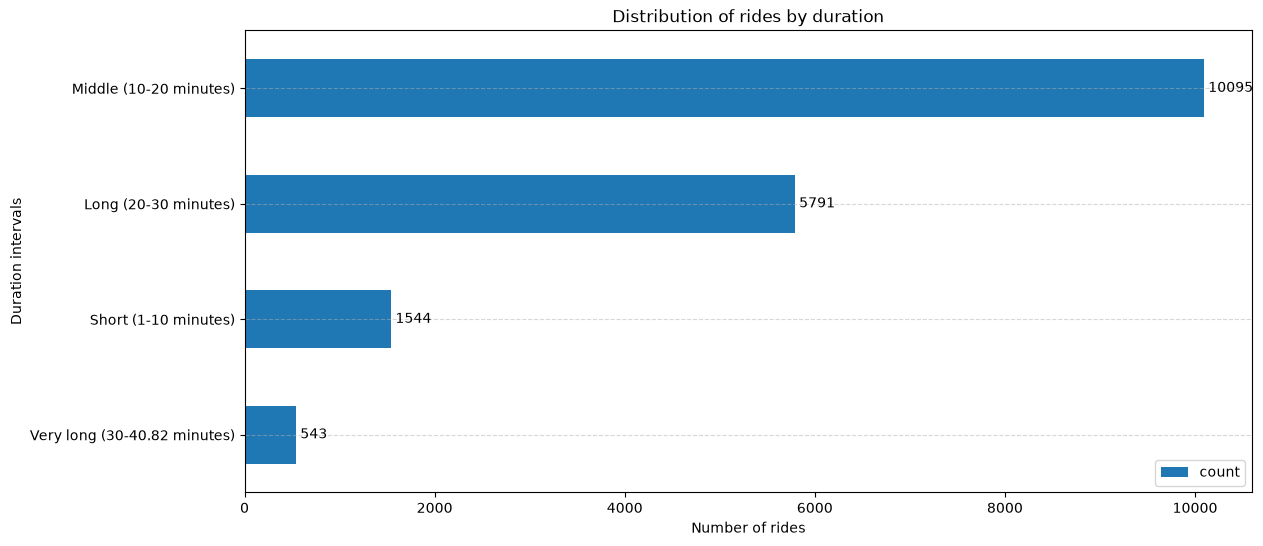

In [30]:
# Build a bar chart using pandas via plot(kind='bar').
df_duration = df_rides_go['duration_group'].value_counts()

# Sort the values in descending order.
df_duration_sorted = df_duration.sort_values(ascending=True)

# Build a bar chart using pandas via plot(kind='bar').
ax=df_duration_sorted.plot(
               kind='barh', 
               rot=0, 
               legend=True, 
               figsize=(13, 6),
               title=f'Distribution of rides by duration'
)

# Add row values.
# Pass the column containers to ax.containers[0]
ax.bar_label(ax.containers[0], padding=3) 

# Set up the graphics design.
plt.ylabel('Duration intervals')
plt.xlabel('Number of rides')

# Add a graph grid.
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Display the graph on the screen.
plt.show()


<div class="alert alert-info">

<h1> Interim conclusions on duration:</h1>

* **Total volume of the analyzed sample:** A total of 17,972 rides are recorded on the graph.
* **“Average duration” (10-20 min.):** This interval is the absolute leader in the number of rides - 10095 rides (which is 56.17% of the total volume).
* **“Long duration” (20-30 minutes):** The second largest segment accounts for 5791 rides (32.22% of all rides).
* **Total share of main intervals:** Medium and long duration rides (from 10 to 30 minutes) total 88.39% (15,886 rides).
* **Segments with smaller volumes:**
  * **"Short duration" (1-10 min.):** 1,544 rides recorded (8.59%).
  * **“Maximum duration” (30-40.82 min.):** The least popular interval is 542 rides (3.02%).

# 5. Data merging

* At first, Let’s combine data about users, rides and subscriptions into one dataframe. We will use the .merge() method with a join type of how='left', which ensures that all original ride records from the df_rides_go table are preserved without losing rows.<br>
* Then we will create two dataframes based on the combined dataframe - with data about users with a subscription and without a subscription.<br>
* Finally we will build visualizations of data on distance and ride time for users of both categories.

In [31]:
# Combine ride data with information about users using the user_id key.
df_merged1 = df_rides_go.merge(df_users_go, on='user_id', how='left')

# Add information about the conditions of subscription types using the subscription_type key.
df_merged2 = df_merged1.merge(df_subscriptions_go, on='subscription_type', how='left')

Check the result of the union. Display the first rows of the new dataframe on the screen.

In [32]:
display(df_merged2.head())

,user_id,distance,duration,date,distance_group,duration_group,name,age,city,subscription_type,age_group,minute_price,start_ride_price,subscription_fee
0,1,4409.918945,25.0,2021-01-01,Long (3000-4500 m),Long (20-30 minutes),кира,22,тюмень,ultra,Young people (18-35),6,0,199
1,1,2617.592041,15.0,2021-01-18,Middle (1500-3000 m),Middle (10-20 minutes),кира,22,тюмень,ultra,Young people (18-35),6,0,199
2,1,754.159790,6.0,2021-04-20,Short (1-1500 m),Short (1-10 minutes),кира,22,тюмень,ultra,Young people (18-35),6,0,199
3,1,2694.783203,18.0,2021-08-11,Middle (1500-3000 m),Middle (10-20 minutes),кира,22,тюмень,ultra,Young people (18-35),6,0,199
4,1,4028.687256,26.0,2021-08-28,Long (3000-4500 m),Long (20-30 minutes),кира,22,тюмень,ultra,Young people (18-35),6,0,199


Display key information about the new dataframe on the screen.

In [33]:
df_merged2.info()

<class 'pandas.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            18068 non-null  Int32         
 1   distance           18067 non-null  float32       
 2   duration           17973 non-null  float64       
 3   date               18068 non-null  datetime64[us]
 4   distance_group     18067 non-null  category      
 5   duration_group     17973 non-null  category      
 6   name               18068 non-null  str           
 7   age                18068 non-null  Int8          
 8   city               18068 non-null  str           
 9   subscription_type  18068 non-null  str           
 10  age_group          18068 non-null  category      
 11  minute_price       18068 non-null  Int16         
 12  start_ride_price   18068 non-null  Int16         
 13  subscription_fee   18068 non-null  Int16         
dtypes: Int16(3), Int3

Display the statistical indicators of the new dataframe on the screen.

In [34]:
df_merged2.describe()

,user_id,distance,duration,date,age,minute_price,start_ride_price,subscription_fee
count,18068.0,18067.000000,17973.000000,18068,18068.0,18068.0,18068.0,18068.0
mean,842.869936,3070.829834,17.394981,2021-06-30 19:47:21.266327,24.893071,7.280496,32.012398,71.590658
min,1.0,2.570787,2.000000,2021-01-01 00:00:00,12.0,6.0,0.0,0.0
25%,487.0,2543.347900,13.000000,2021-04-02 00:00:00,22.0,6.0,0.0,0.0
50%,889.0,3133.674316,17.000000,2021-06-30 00:00:00,25.0,8.0,50.0,0.0
75%,1213.25,3776.251465,21.000000,2021-09-28 00:00:00,28.0,8.0,50.0,199.0
max,1534.0,7211.007812,40.000000,2021-12-30 00:00:00,43.0,8.0,50.0,199.0
std,434.734317,1116.628540,5.979419,NaN,4.582216,0.959882,23.997045,95.508238


4.2 Let’s create two more dataframes from the combined dataframe created in step 4.1:
• with data about users without subscription;
• with data about subscribed users.


In [52]:
df_merged_paying = df_merged2[df_merged2['subscription_type']== 'ultra'].copy()
df_merged_free = df_merged2[df_merged2['subscription_type']== 'free'].copy()

4.3 Let’s build visualizations of data on distance and ride time for users of both categories.

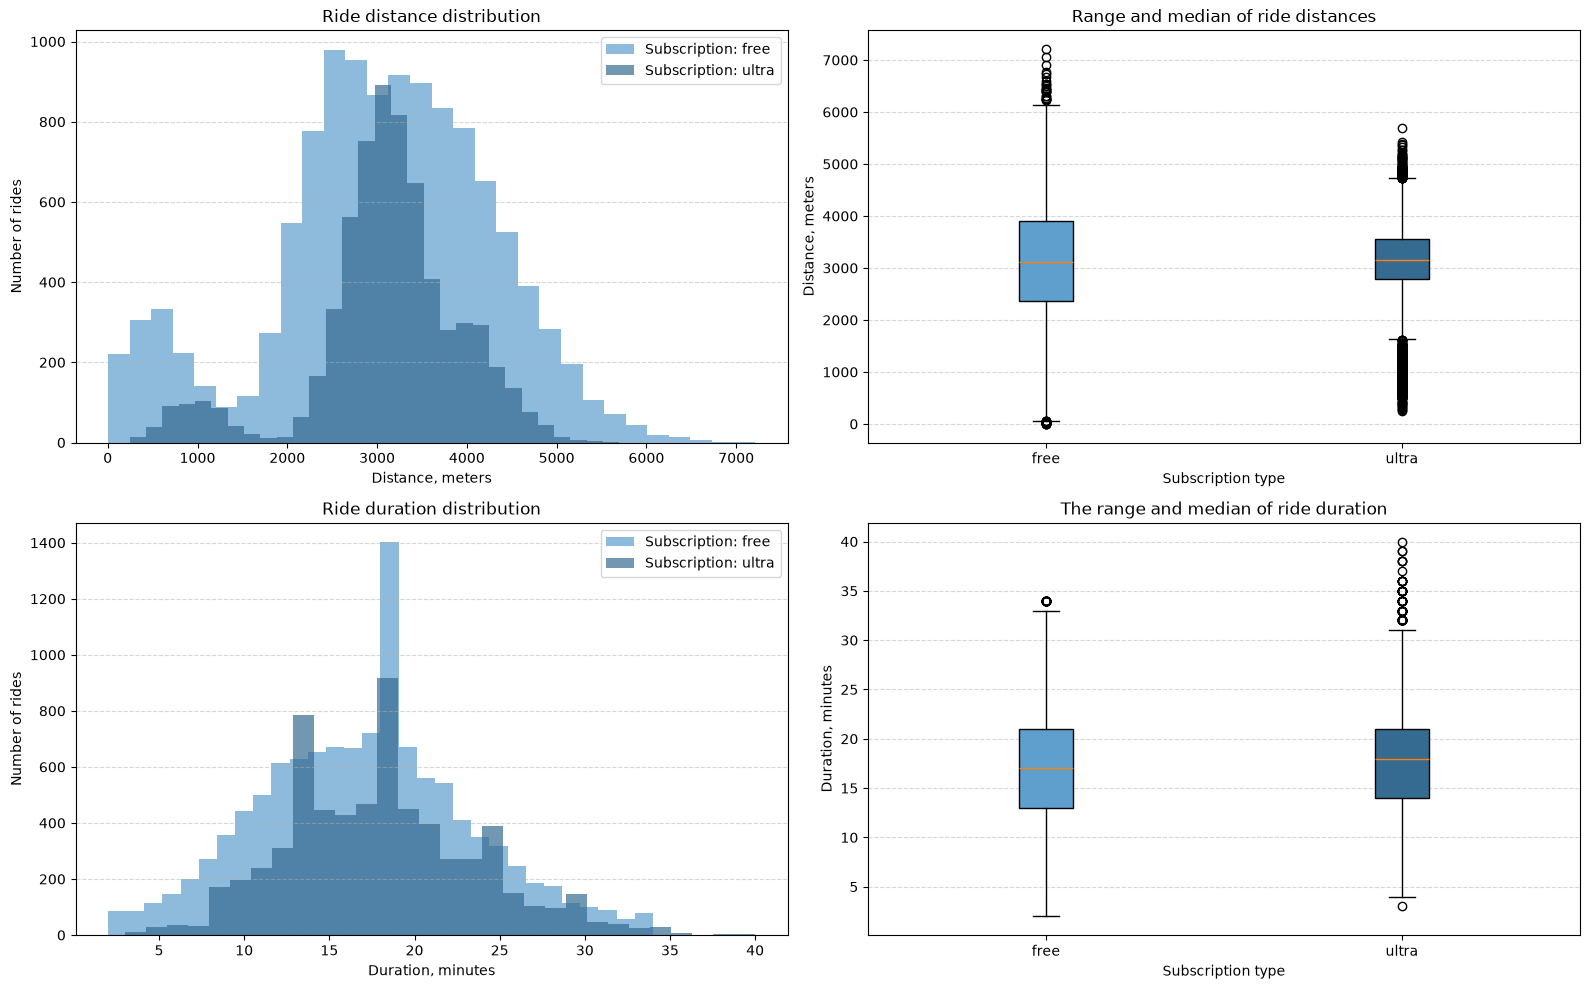

In [36]:
# Set the 'Blues_d' color palette to visualize two user groups.
colors = sns.color_palette('Blues_d', 2)

# Build a 2x2 grid of graphs for continuous metrics of distance and time.
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Let us construct histograms of the distribution of ride distances for both categories.
axes[0, 0].hist(
    df_merged_free['distance'],
    bins=30,
    alpha=0.7,
    color=colors[0],
    label='Subscription: free'
)
axes[0, 0].hist(
    df_merged_paying['distance'],
    bins=30,
    alpha=0.7,
    color=colors[1],
    label='Subscription: ultra'
)
axes[0, 0].set_title('Ride distance distribution')
axes[0, 0].set_xlabel('Distance, meters')
axes[0, 0].set_ylabel('Number of rides')
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.5)
axes[0, 0].legend()

# Build a box and whisker plot to compare ride distances, excluding NaN.
bp_dist = axes[0, 1].boxplot(
    [df_merged_free['distance'].dropna(), df_merged_paying['distance'].dropna()],
    patch_artist=True,
    tick_labels=['free', 'ultra']
)
for patch, color in zip(bp_dist['boxes'], colors):
    patch.set_facecolor(color)
axes[0, 1].set_title('Range and median of ride distances')
axes[0, 1].set_xlabel('Subscription type')
axes[0, 1].set_ylabel('Distance, meters')
axes[0, 1].grid(axis='y', linestyle='--', alpha=0.5)

# Let us construct histograms of the distribution of ride durations for both categories.
axes[1, 0].hist(
    df_merged_free['duration'],
    bins=30,
    alpha=0.7,
    color=colors[0],
    label='Subscription: free'
)
axes[1, 0].hist(
    df_merged_paying['duration'],
    bins=30,
    alpha=0.7,
    color=colors[1],
    label='Subscription: ultra'
)
axes[1, 0].set_title('Ride duration distribution')
axes[1, 0].set_xlabel('Duration, minutes')
axes[1, 0].set_ylabel('Number of rides')
axes[1, 0].grid(axis='y', linestyle='--', alpha=0.5)
axes[1, 0].legend()

# Create a box-and-whiskers plot to compare ride durations, excluding NaN.
bp_dur = axes[1, 1].boxplot(
    [df_merged_free['duration'].dropna(), df_merged_paying['duration'].dropna()],
    patch_artist=True,
    tick_labels=['free', 'ultra']
)
for patch, color in zip(bp_dur['boxes'], colors):
    patch.set_facecolor(color)
axes[1, 1].set_title('The range and median of ride duration')
axes[1, 1].set_xlabel('Subscription type')
axes[1, 1].set_ylabel('Duration, minutes')
axes[1, 1].grid(axis='y', linestyle='--', alpha=0.5)

# Set up the geometric arrangement of the subgraphs.
plt.tight_layout()
plt.show()


<div class="alert alert-info">

<h1>Interim conclusions on the analysis of the distribution of distance and duration of rides</h1>

<h1>Study ride distances</h1>

* **Distribution Shape:** The distance distribution plot shows a bimodal shape for both categories. For users without a subscription ('free'), the first peak is observed in the area of 500-700 m, and the main one - in the range of 2,500-3,000 m. For users with a subscription ('ultra'), the first peak is in the area of 1000 m, the main one - in the range of 3100-3200 m.
* **Medians and range:** The “whisker box” shows the coincidence of median distance values for both groups (about 3100-3150 m). The group without a subscription has a significantly larger interquartile range: 2300-3900 m versus 2800-3550 m for service subscribers, as well as abnormal outliers over 6000 m.

<h1>Assumptions</h1>
* **Variation of usage scenarios for users without a subscription ('free'):** Users with a free subscription use transport for two different scenarios: short rides (up to 1000 m) for the “last mile” (moving between transport hubs) and long rides (over 4,500 m) for walking.
* **Stability of 'ultra' use:** Subscribers use the service for regular routes (e.g. 'home-work-home'), which results in low dispersion and high concentration of values around 3000 m.


<h1>Research on ride durations</h1>
* **Shape of distribution:** Distributions of ride durations for both categories are close to normal with the coincidence of modal values in the range of 17-18 minutes.
* **Medians and outliers:** Users with a subscription have a higher number of abnormal outliers in the range from 33 to 41 minutes.


Display the statistical indicators of dataframes, which we will need in further sections.

In [37]:
print(f'Summary statistics for paying (ultra) users:')
display(df_merged_paying.describe())
print(f'')
print(f'Summary statistics for free users:')
display(df_merged_free.describe())


Summary statistics for paying (ultra) users:


,user_id,distance,duration,date,age,minute_price,start_ride_price,subscription_fee
count,6500.0,6500.000000,6500.000000,6500,6500.0,6500.0,6500.0,6500.0
mean,348.725385,3115.445557,18.037692,2021-06-28 21:31:34.153846,24.892615,6.0,0.0,199.0
min,1.0,244.210434,3.000000,2021-01-01 00:00:00,12.0,6.0,0.0,199.0
25%,175.0,2785.444092,14.000000,2021-04-01 00:00:00,22.0,6.0,0.0,199.0
50%,351.0,3148.637207,18.000000,2021-06-27 00:00:00,25.0,6.0,0.0,199.0
75%,525.0,3560.574524,21.000000,2021-09-25 00:00:00,28.0,6.0,0.0,199.0
max,699.0,5699.769531,40.000000,2021-12-30 00:00:00,38.0,6.0,0.0,199.0
std,201.099339,836.895325,5.577439,NaN,4.757208,0.0,0.0,0.0



Summary statistics for free users:


,user_id,distance,duration,date,age,minute_price,start_ride_price,subscription_fee
count,11568.0,11567.000000,11473.000000,11568,11568.0,11568.0,11568.0,11568.0
mean,1120.52723,3045.758545,17.030855,2021-07-01 21:47:03.236514,24.893326,8.0,50.0,0.0
min,700.0,2.570787,2.000000,2021-01-01 00:00:00,12.0,8.0,50.0,0.0
25%,915.0,2366.586914,13.000000,2021-04-02 00:00:00,22.0,8.0,50.0,0.0
50%,1123.0,3114.655762,17.000000,2021-07-01 00:00:00,25.0,8.0,50.0,0.0
75%,1328.0,3905.791260,21.000000,2021-09-30 00:00:00,28.0,8.0,50.0,0.0
max,1534.0,7211.007812,34.000000,2021-12-30 00:00:00,43.0,8.0,50.0,0.0
std,241.165628,1245.906006,6.166175,NaN,4.4811,0.0,0.0,0.0


# 6. Revenue calculation

* First of all, we will group the combined data from step 4 into columns with user ID, name, subscription type and month number.

* Then we will create a dataframe with aggregated ride data: we will find the total distance, number of rides and total time for each user for each month.

* In the same dataframe, we will add a column with monthly revenue brought in by each user. To do this, please refer to the information about payment terms for subscribers and those who do not have a subscription.


Group the combined data. Then we will create a dataframe with aggregated data.

In [38]:
# Select the month from the date.
df_merged2['month'] = df_merged2['date'].dt.month
df_merged2['duration'] = np.ceil(df_merged2['duration'])

# Group the data by users and months and reset the index.
df_aggregated = df_merged2.groupby(['user_id', 'name', 'subscription_type', 'month']).agg(
    distance_sum=('distance', 'sum'),
    rides_count=('user_id', 'count'),
    duration_sum=('duration', 'sum')
).reset_index()

display(df_aggregated.head())


,user_id,name,subscription_type,month,distance_sum,rides_count,duration_sum
0,1,кира,ultra,1,7027.510742,2,40.0
1,1,кира,ultra,4,754.159790,1,6.0
2,1,кира,ultra,8,6723.470703,2,44.0
3,1,кира,ultra,10,5809.911133,2,30.0
4,1,кира,ultra,11,7003.499512,3,53.0


Add a column with monthly revenue brought in by each user.

<div class="alert alert-info">

Create a function calculate_monthly_revenue(row) to calculate monthly revenue using the formula:

**monthly_revenue = start_ride_price * rides_count + minute_price * total_duration + subscription_fee**

The function will take one row of the dataframe as input.

Here:

`start_ride_price * rides_count` - revenue from the start of each ride.<br>
`minute_price * total_duration` - revenue during use.<br>
`subscription_fee` - fixed revenue from subscriptions.

In [39]:
def calculate_monthly_revenue(df):
    # Create conditions for choosing a subscription type.
    conditions = [
        df['subscription_type'] == 'free',
        df['subscription_type'] == 'ultra'
    ]

    # Set formulas for calculating revenue for each condition.
    choices = [
        (50 * df['rides_count']) + (8 * df['duration_sum']),
        150 + (6 * df['duration_sum'])
    ]

    # Calculate vector revenue values using np.select.
    df['monthly_revenue'] = np.select(conditions, choices, default=0)
    return df


# Apply the function to our aggregated dataframe.
df_aggregated = calculate_monthly_revenue(df_aggregated)


In [40]:
display(df_aggregated.head())

,user_id,name,subscription_type,month,distance_sum,rides_count,duration_sum,monthly_revenue
0,1,кира,ultra,1,7027.510742,2,40.0,390.0
1,1,кира,ultra,4,754.159790,1,6.0,186.0
2,1,кира,ultra,8,6723.470703,2,44.0,414.0
3,1,кира,ultra,10,5809.911133,2,30.0,330.0
4,1,кира,ultra,11,7003.499512,3,53.0,468.0


# 7. Testing hypotheses

Let us formulate and test the following hypotheses.<br>
7.1 It is important to understand whether users with a subscription spend more time traveling? If so, then users with a subscription may be “more profitable” for the company. Test the hypothesis. We use data on the duration of each session - separately for subscribers and those who do not have a subscription.

7.2 The distance of one ride is 3130 meters - optimal from the point of view of scooter wear. Is it possible to say that the distance traveled by users with a subscription in one ride does not exceed 3130 meters? Test the hypothesis and draw conclusions.

7.3. Test the hypothesis about whether the monthly revenue from users with a monthly subscription will be higher than the revenue from users without a subscription. Draw a conclusion.


<div class="alert alert-info">
    
Write a **helper function print_stattest_results (p_value, alpha)** that will interpret the results of a statistical test based on p-value and a given significance level (α-level). 
The function must decide whether to accept the alternative hypothesis or retain the null hypothesis.

The function has two parameters:

* **p_value (float type)** is the p-value obtained as a result of running the statistical test.
* **alpha (float type, optional, default alpha = 0.05)** - the significance level of the statistical test, which is used as a threshold for deciding whether to reject the null hypothesis.
  
If you accept the alternative hypothesis, you need to display the message: 'The resulting p_value =<Entered p_value> is less than the critical level alpha=0.05. We accept the alternative hypothesis.'

If you cannot reject the null hypothesis, you need to display the message: 'The received p_value=<Entered p_value> is greater than the critical level alpha=0.05. The null hypothesis cannot be rejected.'

Call the function for p_value = 0.0001 and p_value = 0.1.

In [41]:
try:
    # Develop a function to interpret the results of a statistical test.
    def print_stattest_results(p_value: float, alpha: float = 0.05):
        if p_value < alpha:
            print(f'The calculated p_value={p_value} is less than the significance level alpha={alpha}. We accept the alternative hypothesis.')
        else:
            print(f'The calculated p_value={p_value} is greater than the significance level alpha={alpha}. The null hypothesis cannot be rejected.')

    # Check the function for test p-values.
    print_stattest_results(0.0001)
    print_stattest_results(0.1)

except Exception as e:
    print(f'Error performing the statistical test: {e}')

The calculated p_value=0.0001 is less than the significance level alpha=0.05. We accept the alternative hypothesis.
The calculated p_value=0.1 is greater than the significance level alpha=0.05. The null hypothesis cannot be rejected.


7.1 **Test the hypothesis: do users with a subscription spend more time on riding?**

To solve this problem, we will use a hypothesis testing algorithm:
1. Define the type of hypothesis: we are dealing with a one-sided hypothesis.
2. Formulate hypotheses:
- **Null hypothesis (H0)**: The average ride time for users with and without a subscription is the same.
- **Alternative Hypothesis (H1)**: The average ride time of users with a subscription is longer than that of users without a subscription.

3. Determine the significance level - let the significance level be at the level of 0.05.
4. Build the sampling distribution.
5. Calculate p-value.
6. Compare p-value with α.

Build the sampling distribution.

In [42]:
# Clear the samples from NaN and non-numeric values.
cleaned_durations_paying = df_merged_paying[df_merged_paying['duration'] == df_merged_paying['duration']]
cleaned_durations_free = df_merged_free[df_merged_free['duration'] == df_merged_free['duration']]

# Conduct a two-sample Student's t-test.
results = st.ttest_ind(
    cleaned_durations_paying['duration'],
    cleaned_durations_free['duration'],
    alternative='greater'
    )

# Call the function to interpret the results of the statistical test.
print_stattest_results(results.pvalue, alpha=0.05)

# Calculate the average ride duration for each category of users.
paying_mean = (cleaned_durations_paying['duration'].mean().round(2))
free_mean = (cleaned_durations_free['duration'].mean().round(2))
print(f'Average ride duration among ultra users: {paying_mean:.2f} мин.')
print(f'Average ride duration among free users: {free_mean:.2f} мин.')

The calculated p_value=8.57791034779626e-28 is less than the significance level alpha=0.05. We accept the alternative hypothesis.
Average ride duration among ultra users: 18.04 мин.
Average ride duration among free users: 17.03 мин.


7.2 **Check the hypothesis: the distance traveled by users with a subscription in one ride does not exceed 3130 meters**

To solve this problem, we will use a hypothesis testing algorithm:

1. Define the type of hypothesis: we are dealing with a one-sided hypothesis.
   
2. Let’s formulate hypotheses:
   - **Null hypothesis (H0)**: The average ride distance for users with a subscription is 3130 m.
   - **Alternative hypothesis (H1)**: The average ride distance for users with a subscription is less than 3130 m.<br><br>
     
3. Determine the significance level - let the significance level be at the level of 0.05.
4. Build the sampling distribution.
5. Calculate p-value.
6. Compare p-value with α.

Build the sampling distribution.

In [53]:
# Set the ride distances of users with a subscription ('ultra').
cleaned_paying_distances = df_merged_paying['distance'].dropna()

# Set the optimal distance value.
expected_distance = 3130

# Conduct a one-sample Student's t-test for the cleaned sample.
results = st.ttest_1samp(
    cleaned_paying_distances, 
    expected_distance,
    alternative='less')

# Call the function to interpret the results of the statistical test.
print_stattest_results(results.pvalue, alpha=0.05)

The calculated p_value=0.08046554774045944 is greater than the significance level alpha=0.05. The null hypothesis cannot be rejected.


7.3. **Test the hypothesis about whether the monthly revenue from users with a monthly subscription will be higher than the revenue from users without a subscription.**

To solve this problem, we will use a hypothesis testing algorithm:

1. Define the type of hypothesis: we are dealing with a one-sided hypothesis.
   
2. Let’s formulate hypotheses:
   - **Null Hypothesis (H0)**: Monthly revenue from users with a subscription is less than revenue from users without a subscription.
   - **Non-null hypothesis (H1)**: Monthly revenue from users with a subscription is higher than revenue from users without a subscription.

Formalize the hypotheses:
H0: monthly_revenue_paying < monthly_revenue_free <br>
H0: monthly_revenue_paying > monthly_revenue_free <br>

3. Determine the significance level - let the significance level be at the level of 0.05.
4. Build the sampling distribution.
5. Calculate p-value.
6. Compare p-value with α.

Build the sampling distribution.

In [44]:
# Set monthly revenue.
paying_revenues = df_aggregated[df_aggregated['subscription_type']=='ultra']['monthly_revenue']
free_revenues = df_aggregated[df_aggregated['subscription_type']=='free']['monthly_revenue']

# Set the level of statistical significance.
alpha = 0.05

# Run a two-sample test on the cleaned sample.
results = st.ttest_ind(
    paying_revenues, 
    free_revenues,
    alternative='greater')

# Call the function to interpret the results of the statistical test.
print_stattest_results(results.pvalue, alpha=0.05)


The calculated p_value=0.9997513892665916 is greater than the significance level alpha=0.05. The null hypothesis cannot be rejected.


# 8. Distributions

To estimate the share of rides longer than 30 minutes-under the discount idea for subscribers-we model their duration as a normal distribution. There is no completeness of data for all users, so we will take the parameters (average and standard deviation) from a previously analyzed sample.

8.1 **Calculate the average ride duration and standard deviation of duration based on the sample.**

8.2 **Build the distribution function CDF**.
The value of the distribution function (CDF) at a point shows the probability that the random variable will not exceed a given number. Therefore, to determine the probability of a ride longer than 30 minutes, we will use the opposite value: 1 − CDF(30).

8.3 **Calculate Probability for interval (CDF)**.

8.4 **Find the distance that is exceeded in only 10% of rides (90th percentile)**.

8.1 Calculate the average ride duration and standard deviation of duration based on the sample.

In [1]:
# Set the parameters of the normal distribution.
# Calculate the average duration of the ride and save it in the mu variable.
mu = df_merged2['duration'].mean()

# Calculate the standard deviation of the ride duration and save it in the sigma variable.
sigma = df_merged2['duration'].std()

# Determine the value for which we will calculate the distribution function.
target_time = 30

# We will display the results rounded to one decimal place when printing.
print(f'Mean ride duration (mu): {mu:.1f}')
print(f'Standard deviation of ride duration (sigma): {round(sigma, 1)}')
print(f'Target duration (target_time): {round(target_time, 1)}')

NameError: name 'df_merged2' is not defined

8.2 Build the distribution function CDF. 

The value of the distribution function (CDF) at a point shows the probability that the random variable will not exceed a given number. Therefore, to determine the probability of a ride longer than 30 minutes, we use the opposite value: 1 − CDF(30).

In [54]:
# Create a normal distribution object with parameters mu and sigma.
dist = st.norm(mu, sigma)

# Calculate the probability that a random variable is less than or equal to the specified value.
prob = dist.cdf(target_time)  # Using CDF to find the accumulated probability
prob_adjusted = 1 - prob

# We will display the result as a formatted string with the probability rounded to two digits.
print(f"The probability that a paying user's ride will be longer than {target_time} minutes: {prob_adjusted:.2f}")


The probability that a paying user's ride will be longer than 30 minutes: 1.00


8.3 Probability for interval (CDF)
Since the percentage of paying users for whom the discount will be shown is not large enough (only 3%) and is unlikely to significantly increase the base of loyal customers, we will additionally check what percentage of users make rides in the range of 20 to 30 minutes. Perhaps it is worth holding a promotion just for them.

In [47]:
# Set the target value of the time interval for subsequent probability calculations.
low = 20
high = 30

# Calculate the probability of the ride duration falling into the interval from low to high.
prob_interval = round(st.norm.cdf(high, loc=mu, scale=sigma) - st.norm.cdf(low, loc=mu, scale=sigma), 3)

# We will display the results rounded to one decimal place when printing.
print(f'The probability that a user will make a ride with a duration from {low} to {high} minutes: {prob_interval}')

The probability that a user will make a ride with a duration from 20 to 30 minutes: 0.314


8.4 Find the distance that is exceeded in only 10% of rides (90th percentile).

Long rides can negatively affect the life of the scooter. In this regard, it was decided to establish a critical distance, exceeding which will be accompanied by an additional fee. To do this, you need to determine the distance that is exceeded in only 10% of rides (90th percentile).

Our task is to model the distribution of ride durations, assuming that it follows a normal law, and calculate the critical distance below which 90% of all rides are located.

In [55]:
# Calculate the average duration of the ride and save it in the mu variable.
mu = df_merged2['distance'].mean()

# Calculate the standard deviation of the ride duration and save it in the sigma variable.
sigma = df_merged2['distance'].std()

# Set the probability for which we want to find the value (90% of cases).
prob = 0.90

# Create a normal distribution object with parameters mu and sigma.
dist = st.norm(mu, sigma)

# We use the ppf() method to find the value corresponding to the 90% probability.
# ppf() returns the value of the random variable below which 90% of all cases lie
value = dist.ppf(prob)

# Display the result on the screen: the distance value below which 90% of the probabilities are located.
print(f"The ride distance corresponding to a 90% probability: {value:.2f} m")


The ride distance corresponding to a 90% probability: 4501.85 m


# GoFast Scooter Rental Service Analysis - Final conclusions:

GoFast scooter rental service research highlights core demographic patterns, usage characteristics, and key monetization benefits associated with paid subscriptions.

**User Demographics and Scooter Usage**
* **User Base Scope:** The service counts 1534 unique users across 8 cities.
* **Age Demographics:** User ages range from 12 to 43 years, with a mean age of 24.92 years and a median age of 25 years.
* **Ride Distance:** Across 18068 recorded rides, the average distance traveled per ride is 3070.83 meters, with a median distance of 3133.67 meters.
* **Ride Duration:** The average ride duration is 17.39 minutes, with a median session length of 17 minutes.
* **Anomalous Data:** Approximately 0.5% of sessions with near-zero duration or distance were identified and isolated as technical glitches or immediate ride cancellations.

**Benefits of Distributing Paid Subscriptions**
* **Subscriber Breakdown:** The customer base includes 846 users on the Free plan, alongside Ultra subscription holders.
* **Cost Difference:** Free tier users pay a 50 start fee and 8 per minute with a 0 monthly fee, whereas Ultra subscribers pay a 199 monthly fee, 0 start fee, and 6 per minute.
* **Predictable Revenue:** Promoting Ultra subscriptions secures stable monthly recurring revenue through the 199 subscription fee, reducing reliance on per-ride start fees.
* **User Engagement:** Eliminating the 50 start cost lowers the entry barrier per ride, encouraging users to take more frequent short rides and boosting overall retention.

# Strategic Recommendations


* **Prioritize marketing campaigns** toward converting free users to the "ultra" subscription, aiming to maximize monthly revenue based on duration trends.
* **Implement the proposed discount for targeted time intervals** (e.g., 20-30 minutes) to increase customer loyalty among the most active demographic.
* **Introduce a critical distance surcharge** past the 90th percentile threshold to mitigate excessive wear-and-tear costs from prolonged trips over the optimal 3,130 meters.